# Part 1  : SQL Queries
----------------------------------

# **Imports**
-------------------------------------------------------------


In [11]:
# Sqlite is a library that implements a SQL database engine.
import sqlite3
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.getcwd()


'/content'

**Reading File**
------------------------------------------------------------------------------

In [12]:
conn = sqlite3.connect("/content/olist.sqlite")


In [13]:
tables = pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type='table';
""", conn)

tables

,name
0,product_category_name_translation
1,sellers
2,customers
3,geolocation
4,order_items
5,order_payments
6,order_reviews
7,orders
8,products
9,leads_qualified


# Query 1:

 # order per month
 ----------------------------------------------------------

In [14]:
pd.read_sql("""SELECT * FROM orders;""",conn)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [15]:
df_month = pd.read_sql("""SELECT
    strftime('%Y-%m', order_purchase_timestamp) AS order_month,
    COUNT(*) AS num_orders
FROM orders
GROUP BY order_month
ORDER BY num_orders desc
LIMIT 10
;""",
            conn


)
df_month

,order_month,num_orders
0,2017-11,7544
1,2018-01,7269
2,2018-03,7211
3,2018-04,6939
4,2018-05,6873
5,2018-02,6728
6,2018-08,6512
7,2018-07,6292
8,2018-06,6167
9,2017-12,5673


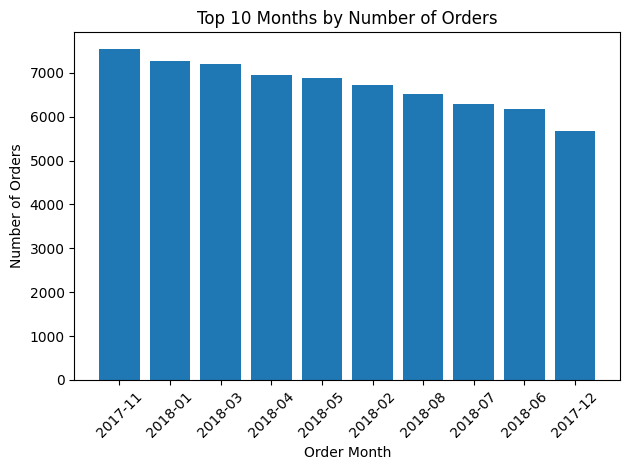

In [16]:
plt.figure()
plt.bar(df_month['order_month'], df_month['num_orders'])
plt.xlabel('Order Month')
plt.ylabel('Number of Orders')
plt.title('Top 10 Months by Number of Orders')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Query 2:
 # Revenue by Product Category
 -------------------------------------------------------------------

In [17]:
# order iimes table
pd.read_sql(""" SELECT * FROM order_items;""",conn)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [18]:
#product table
pd.read_sql("""SELECT * FROM products ;""",conn)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [19]:
df_rev = pd.read_sql("""SELECT p.product_category_name,
            SUM(oi.price) AS total_rvenue
            FROM order_items oi
            JOIN products p ON oi.product_id = p.product_id
            GROUP BY p.product_category_name
            ORDER BY total_rvenue
            LIMIT 5;""",conn

)
df_rev

,product_category_name,total_rvenue
0,seguros_e_servicos,283.29
1,fashion_roupa_infanto_juvenil,569.85
2,cds_dvds_musicais,730.00
3,casa_conforto_2,760.27
4,flores,1110.04


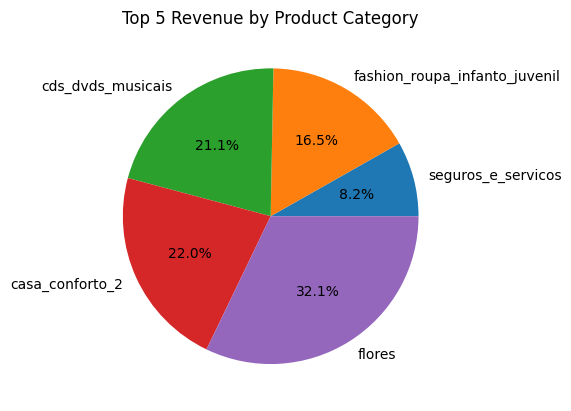

In [20]:
plt.figure()
plt.pie(
    df_rev['total_rvenue'],
labels=df_rev['product_category_name'],
    autopct='%1.1f%%'
)

plt.title('Top 5 Revenue by Product Category')
plt.show()

# Query 3:

 # 3)Top 10 Customers by Revenue
 --------------------------------------------

In [21]:
# costumer tabel
pd.read_sql("""SELECT * FROM customers;""",conn)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


In [22]:
pd.read_sql("""SELECT * FROM orders;""",conn)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [23]:
pd.read_sql(""" SELECT * FROM order_items;""",conn)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [24]:
df_cust = pd.read_sql("""SELECT c.customer_unique_id ,
            SUM(oi.price) AS total_rvenue
            FROM orders o
            JOIN customers c ON  o.customer_id = c.customer_id
            JOIN order_items oi ON oi.order_id= o.order_id
            GROUP BY c.customer_unique_id
            ORDER BY total_rvenue DESC
            LIMIT 10 ;""",conn



)
df_cust

,customer_unique_id,total_rvenue
0,0a0a92112bd4c708ca5fde585afaa872,13440.0
1,da122df9eeddfedc1dc1f5349a1a690c,7388.0
2,763c8b1c9c68a0229c42c9fc6f662b93,7160.0
3,dc4802a71eae9be1dd28f5d788ceb526,6735.0
4,459bef486812aa25204be022145caa62,6729.0
5,ff4159b92c40ebe40454e3e6a7c35ed6,6499.0
6,4007669dec559734d6f53e029e360987,5934.6
7,eebb5dda148d3893cdaf5b5ca3040ccb,4690.0
8,5d0a2980b292d049061542014e8960bf,4599.9
9,48e1ac109decbb87765a3eade6854098,4590.0


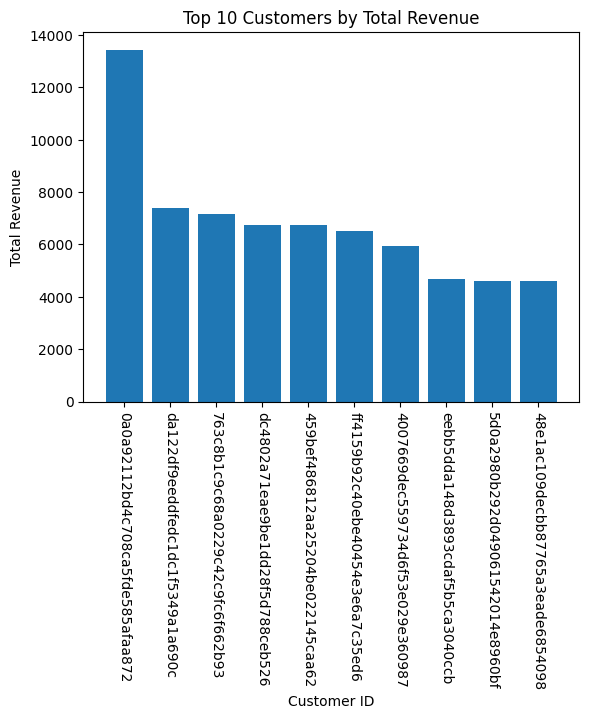

In [25]:
plt.figure()
plt.bar(df_cust['customer_unique_id'], df_cust['total_rvenue'])
plt.xlabel('Customer ID')
plt.ylabel('Total Revenue')
plt.title('Top 10 Customers by Total Revenue')
plt.xticks(rotation=-90)


plt.show()

# Query 4:
# Products with Highest Number of Orders
-----------------------------------------------------------

In [26]:
df_prod = pd.read_sql("""
SELECT
    p.product_id,
    COUNT(oi.order_id) AS num_orders
FROM order_items oi
JOIN products p ON oi.product_id = p.product_id
GROUP BY p.product_id
ORDER BY num_orders DESC
LIMIT 10;
""", conn)
df_prod



,product_id,num_orders
0,aca2eb7d00ea1a7b8ebd4e68314663af,527
1,99a4788cb24856965c36a24e339b6058,488
2,422879e10f46682990de24d770e7f83d,484
3,389d119b48cf3043d311335e499d9c6b,392
4,368c6c730842d78016ad823897a372db,388
5,53759a2ecddad2bb87a079a1f1519f73,373
6,d1c427060a0f73f6b889a5c7c61f2ac4,343
7,53b36df67ebb7c41585e8d54d6772e08,323
8,154e7e31ebfa092203795c972e5804a6,281
9,3dd2a17168ec895c781a9191c1e95ad7,274


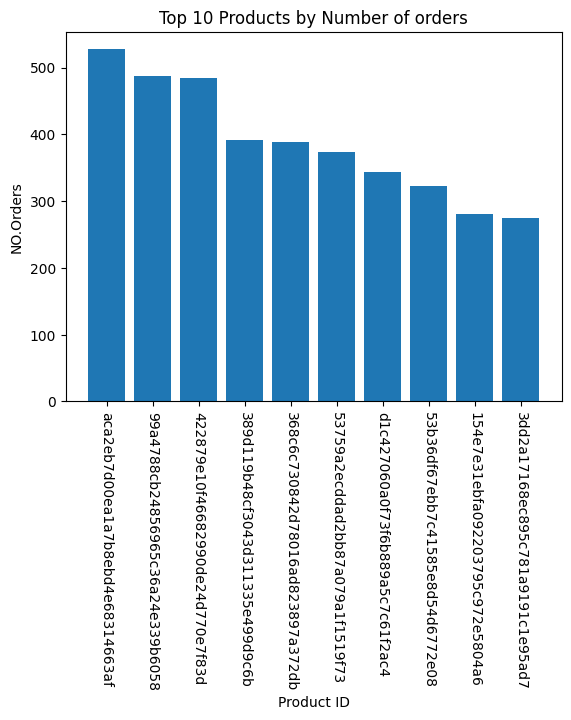

In [27]:
plt.figure()
plt.bar(df_prod['product_id'], df_prod['num_orders'])
plt.xlabel('Product ID')
plt.ylabel('NO.Orders')
plt.title('Top 10 Products by Number of orders')
plt.xticks(rotation=-90)


plt.show()

#Query 5:
# Review Scores Distribution
---------------------------------------------------------

In [28]:
df_scores = pd.read_sql("""SELECT review_score,
count(order_id) AS num_orders,
 ROUND(
        COUNT(order_id) * 100.0 / SUM(COUNT(order_id)) OVER (),
        2
    ) || '%' AS percentage
FROM order_reviews
GROUP BY review_score;""", conn

)
df_scores

,review_score,num_orders,percentage
0,1,11424,11.51%
1,2,3151,3.18%
2,3,8179,8.24%
3,4,19142,19.29%
4,5,57328,57.78%


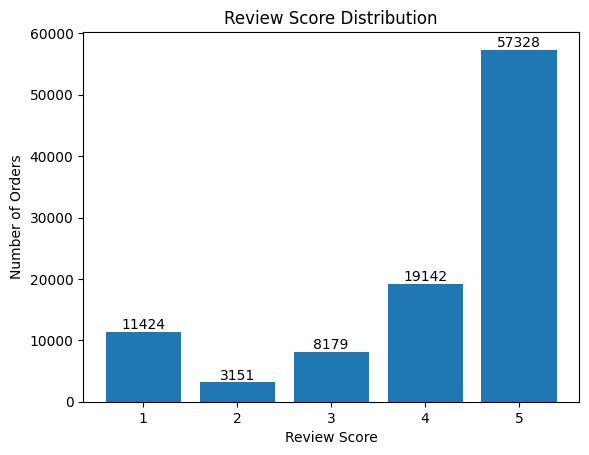

In [29]:
plt.figure()
bars = plt.bar(df_scores['review_score'], df_scores['num_orders'])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{int(height)}',
             ha='center', va='bottom')

plt.xlabel('Review Score')
plt.ylabel('Number of Orders')
plt.title('Review Score Distribution')
plt.xticks([1,2,3,4,5])
plt.show()

# Part 2:
# Python Data Analysis
-----------------------------------------

 # 6) data Preprocessing
 ---------------------------------------

In [30]:
#check the shape and structure of all tables
query = "SELECT name FROM sqlite_master WHERE type='table';"
tables_list = pd.read_sql(query, conn)['name'].tolist()

for table in tables_list:
    df = pd.read_sql(f"SELECT * FROM {table}", conn)

    print(f"Table: {table}  ----> Rows: {df.shape[0]}, Columns: {df.shape[1]}")


Table: product_category_name_translation  ----> Rows: 71, Columns: 2
Table: sellers  ----> Rows: 3095, Columns: 4
Table: customers  ----> Rows: 99441, Columns: 5
Table: geolocation  ----> Rows: 1000163, Columns: 5
Table: order_items  ----> Rows: 112650, Columns: 7
Table: order_payments  ----> Rows: 103886, Columns: 5
Table: order_reviews  ----> Rows: 99224, Columns: 7
Table: orders  ----> Rows: 99441, Columns: 8
Table: products  ----> Rows: 32951, Columns: 9
Table: leads_qualified  ----> Rows: 8000, Columns: 4
Table: leads_closed  ----> Rows: 842, Columns: 14


In [31]:
total_nulls = df.isnull().sum().sum()
print(f" Total Missing Values: {total_nulls}")

 Total Missing Values: 3300


In [32]:
key_cols = [col for col in df.columns if 'id' in col]
if key_cols:
        null_keys = df[key_cols].isnull().sum().sum()
        print(f"Missing values in Key Columns (IDs): {null_keys}")





Missing values in Key Columns (IDs): 0



# 1 We observe that the number of missing values in key columns (customer_id, order_id) is zero across all main tables.


---


# **2 The Significance:**
-------------------------------------------------

1----> Data Integrity: There are no "anonymous" orders or customers. Every record is correctly identified.






2---> Reliable Joins: Since there are no missing IDs, we can merge all tables safely without losing any data.



3-----> Accurate RFM Analysis: Having complete ID columns ensures that our Frequency and Monetary calculations will be 100% accurate.










4--------> High Data Quality: Zero missing values in key columns indicates a well-structured database ready for analysis.

In [33]:
import pandas as pd
missing_data_list = []

for table in tables_list:
    df = pd.read_sql(f"SELECT * FROM {table}", conn)
    null_counts = df.isnull().sum()

    if null_counts.sum() > 0:
        null_only = null_counts[null_counts > 0]

        for col, count in null_only.items():
            missing_data_list.append({
                'Table Name': table,
                'Column Name': col,
                'Missing Values': count,
                'Percentage (%)': (count / len(df)) * 100
            })

summary_df = pd.DataFrame(missing_data_list)

summary_df.style.background_gradient(cmap='Reds', subset=['Missing Values'])\
    .format({'Percentage (%)': "{:.2f}%"})\
    .set_caption(" Missing Values Summary Report")

,Table Name,Column Name,Missing Values,Percentage (%)
0,order_reviews,review_comment_title,87656,88.34%
1,order_reviews,review_comment_message,58247,58.70%
2,orders,order_approved_at,160,0.16%
3,orders,order_delivered_carrier_date,1783,1.79%
4,orders,order_delivered_customer_date,2965,2.98%
5,products,product_category_name,610,1.85%
6,products,product_name_lenght,610,1.85%
7,products,product_description_lenght,610,1.85%
8,products,product_photos_qty,610,1.85%
9,products,product_weight_g,2,0.01%


# 7 Basic EDA with Pandas
-------------------------------------

In [34]:
query_q7 = """
SELECT
    COUNT(customer_id) AS total_customer_ids,
    COUNT(DISTINCT customer_unique_id) AS unique_customers
FROM Customers;
"""

df_q7 = pd.read_sql(query_q7, conn)
print(df_q7)

order_count = pd.read_sql("SELECT COUNT(DISTINCT order_id) AS total_orders FROM Orders;", conn)
print(order_count)
avgOrderPerCust = pd.read_sql("""SELECT
    COUNT(DISTINCT order_id) * 1.0 / COUNT(DISTINCT customer_unique_id) AS avg_orders_per_customer
FROM Orders o
JOIN Customers c
ON o.customer_id = c.customer_id; """, conn)

print(avgOrderPerCust)

   total_customer_ids  unique_customers
0               99441             96096
   total_orders
0         99441
   avg_orders_per_customer
0                 1.034809




#The number of orders is higher than the number of unique customers

#Business Insight:
--------------------------


 This indicates that some customers are "Repeat Buyers" who have made
more than one purchase.
But mostly the average buying is 1 order per customer



 We will analyze this behavior further in the Frequency (F) part of our RFM analysis

# 8-Revenue Analysis
------------------------------------------------------

In [35]:
query_q8 = """
SELECT
    c.customer_unique_id,
    SUM(p.payment_value) AS total_spent,
    COUNT(DISTINCT o.order_id) AS number_of_orders
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN order_payments p ON o.order_id = p.order_id
GROUP BY c.customer_unique_id
ORDER BY total_spent DESC;
"""

customer_revenue = pd.read_sql(query_q8, conn)

print(customer_revenue.head(10))



#IMPORTANT INSIGHT : 0  0a0a92112bd4c708ca5fde585afaa872     13664.08                 1

# This customer is a Big Spender with high Monetary value but low Frequency.

                 customer_unique_id  total_spent  number_of_orders
0  0a0a92112bd4c708ca5fde585afaa872     13664.08                 1
1  46450c74a0d8c5ca9395da1daac6c120      9553.02                 3
2  da122df9eeddfedc1dc1f5349a1a690c      7571.63                 2
3  763c8b1c9c68a0229c42c9fc6f662b93      7274.88                 1
4  dc4802a71eae9be1dd28f5d788ceb526      6929.31                 1
5  459bef486812aa25204be022145caa62      6922.21                 1
6  ff4159b92c40ebe40454e3e6a7c35ed6      6726.66                 1
7  4007669dec559734d6f53e029e360987      6081.54                 1
8  5d0a2980b292d049061542014e8960bf      4809.44                 1
9  eebb5dda148d3893cdaf5b5ca3040ccb      4764.34                 1


# 9-Customer Segmentation
-----------------------------------------------

In [36]:
#Step 1: : Using Python and Pandas, calculate the Recency (R), Frequency (F), and Monetary (M) features for each customer.


df_all = pd.read_sql("""
    SELECT c.customer_unique_id, o.order_purchase_timestamp, p.payment_value, o.order_id
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    JOIN order_payments p ON o.order_id = p.order_id
""", conn)

In [37]:
df_all['order_purchase_timestamp'] = pd.to_datetime(df_all['order_purchase_timestamp'])

In [38]:
last_date = df_all['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

In [39]:
df_recency = df_all.groupby(by='customer_unique_id', as_index=False)['order_purchase_timestamp'].max()
df_recency.columns = ['customer_unique_id', 'LastPurchaseDate']

recent_date = df_recency['LastPurchaseDate'].max()

df_recency['Recency'] = df_recency['LastPurchaseDate'].apply(lambda x: (recent_date - x).days)

df_recency.head(10)

,customer_unique_id,LastPurchaseDate,Recency
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,160
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,163
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,585
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,369
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,336
5,0004bd2a26a76fe21f786e4fbd80607f,2018-04-05 19:33:16,194
6,00050ab1314c0e55a6ca13cf7181fecf,2018-04-20 12:57:23,180
7,00053a61a98854899e70ed204dd4bafe,2018-02-28 11:15:41,231
8,0005e1862207bf6ccc02e4228effd9a0,2017-03-04 23:32:12,591
9,0005ef4cd20d2893f0d9fbd94d3c0d97,2018-03-12 15:22:12,219


In [40]:
df_frequency = df_all.groupby(by='customer_unique_id', as_index=False)['order_id'].nunique()
df_frequency.columns = ['customer_unique_id', 'Frequency']

df_frequency.head(10)

,customer_unique_id,Frequency
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1
5,0004bd2a26a76fe21f786e4fbd80607f,1
6,00050ab1314c0e55a6ca13cf7181fecf,1
7,00053a61a98854899e70ed204dd4bafe,1
8,0005e1862207bf6ccc02e4228effd9a0,1
9,0005ef4cd20d2893f0d9fbd94d3c0d97,1


In [41]:
df_monetary = df_all.groupby(by='customer_unique_id', as_index=False)['payment_value'].sum()
df_monetary.columns = ['customer_unique_id', 'Monetary']

df_monetary.head(10)

,customer_unique_id,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19
2,0000f46a3911fa3c0805444483337064,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,43.62
4,0004aac84e0df4da2b147fca70cf8255,196.89
5,0004bd2a26a76fe21f786e4fbd80607f,166.98
6,00050ab1314c0e55a6ca13cf7181fecf,35.38
7,00053a61a98854899e70ed204dd4bafe,419.18
8,0005e1862207bf6ccc02e4228effd9a0,150.12
9,0005ef4cd20d2893f0d9fbd94d3c0d97,129.76


In [42]:
#The RFM Table:

rfm_df = df_recency.merge(df_frequency, on='customer_unique_id')

rfm_df = rfm_df.merge(df_monetary, on='customer_unique_id')

rfm_df.drop(columns=['LastPurchaseDate'], inplace=True)

rfm_df.head(10)

,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19
2,0000f46a3911fa3c0805444483337064,585,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,336,1,196.89
5,0004bd2a26a76fe21f786e4fbd80607f,194,1,166.98
6,00050ab1314c0e55a6ca13cf7181fecf,180,1,35.38
7,00053a61a98854899e70ed204dd4bafe,231,1,419.18
8,0005e1862207bf6ccc02e4228effd9a0,591,1,150.12
9,0005ef4cd20d2893f0d9fbd94d3c0d97,219,1,129.76


In [44]:
rfm_df['R_Score'] = pd.qcut(rfm_df['Recency'], 5, labels=[5, 4, 3, 2, 1])

In [46]:
rfm_df['F_Score'] = pd.qcut(rfm_df['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])

In [48]:
rfm_df['M_Score'] = pd.qcut(rfm_df['Monetary'], 5, labels=[1, 2, 3, 4, 5])

In [49]:
rfm_df['RFM_Score'] = rfm_df['R_Score'].astype(str) + rfm_df['F_Score'].astype(str) + rfm_df['M_Score'].astype(str)

In [51]:
rfm_df_styled = rfm_df.head(10).style.set_properties(**{
    'background-color': '#1e1e1e',
    'color': '#d4d4d4',
    'border': '1px solid #333333',
    'text-align': 'center'
})

rfm_df_styled = rfm_df_styled.set_table_styles([
    {'selector': 'th', 'props': [
        ('background-color', '#2d2d2d'),
        ('color', '#ffffff'),
        ('font-weight', 'bold'),
        ('border', '1px solid #444444'),
        ('text-align', 'center')
    ]}
])

rfm_df_styled = rfm_df_styled.set_properties(subset=['RFM_Score'], **{
    'color': '#ce9178',
    'font-weight': 'bold'
})

rfm_df_styled

,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.900000,4,1,4,414
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.190000,4,1,1,411
2,0000f46a3911fa3c0805444483337064,585,1,86.220000,1,1,2,112
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,43.620000,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,336,1,196.890000,2,1,4,214
5,0004bd2a26a76fe21f786e4fbd80607f,194,1,166.980000,4,1,4,414
6,00050ab1314c0e55a6ca13cf7181fecf,180,1,35.380000,4,1,1,411
7,00053a61a98854899e70ed204dd4bafe,231,1,419.180000,3,1,5,315
8,0005e1862207bf6ccc02e4228effd9a0,591,1,150.120000,1,1,4,114
9,0005ef4cd20d2893f0d9fbd94d3c0d97,219,1,129.760000,4,1,3,413


# **#What are the different customer segments you can identify based on their RFM score?**
---------------------------------------------------------------------

'''By combining the R, F, and M scores, we can identify several segments
1------> Champions (Score 555): Best customers who bought recently, buy often, and spend the most.

2------>At Risk: Customers who haven't purchased in a long time (Low R_Score) but used to spend a lot.

3------>New Customers (Score 511): Customers who just made their first purchase.

4------>Lost Customers (Score 111): Customers with the lowest activity across all metrics.'''

# 10-RFM Visualization
--------------------------------------------------------

In [55]:
import plotly.express as px


def assign_segment(rfm_score):
    r = int(rfm_score[0])
    f = int(rfm_score[1])
    m = int(rfm_score[2])

    if r == 5 and f == 5 and m == 5:
        return 'Champions'
    elif r >= 4 and f >= 4 and m >= 4:
        return 'Loyal/Valuable'
    elif r >= 4 and f == 1 and m == 1:
        return 'New Customers'
    elif r <= 2 and f >= 2 and m >= 2:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost Customers'
    elif f >= 4 and m >= 4:
        return 'Potential Loyalists'
    elif r >= 4 and m >= 4:
        return 'Promising'
    else:
        return 'Others'

rfm_df['Segment'] = rfm_df['RFM_Score'].apply(assign_segment)

segment_counts = rfm_df['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']

fig = px.treemap(segment_counts,
                 path=['Segment'],
                 values='Count',
                 title='Customer Segmentation (RFM Tree Map)',
                 color='Count',
                 color_continuous_scale='Blues')

fig.update_layout(title_x=0.5, template='plotly_dark')

fig.show()

#Q10 Insights:
-----------------------------------------

'''1 -----> The Treemap shows that a significant portion of our customer base falls into the "At Risk" and "Others" segments.











---













2 ---------> The "At Risk" segment is quite large, indicating that many customers who were previously valuable are now inactive. This requires immediate marketing intervention.












---









3-----------> High-value segments like "Champions" represent a very small area, suggesting a need for loyalty programs to convert more customers into frequent buyers.

 # **Part 3: Advanced Python and Business Strategy**
 ----------------------------------------------------------------------------

Q11: Customer Retention Strategy
----------------------------------------

In [63]:
at_risk_customers = rfm_df[rfm_df['Segment'] == 'At Risk']

at_risk_analysis = at_risk_customers.merge(df_reviews, on='customer_unique_id', how='left')

avg_at_risk_score = at_risk_analysis['review_score'].mean()

at_risk_analysis['order_delivered_customer_date'] = pd.to_datetime(at_risk_analysis['order_delivered_customer_date'])
at_risk_analysis['order_estimated_delivery_date'] = pd.to_datetime(at_risk_analysis['order_estimated_delivery_date'])
at_risk_analysis['is_delayed'] = (at_risk_analysis['order_delivered_customer_date'] > at_risk_analysis['order_estimated_delivery_date'])

at_risk_delay_rate = at_risk_analysis['is_delayed'].dropna().mean() * 100

print(f"Average Review Score for At Risk Customers: {avg_at_risk_score:.2f}")
print(f"Percentage of delayed orders for At Risk Customers: {at_risk_delay_rate:.2f}%")

Average Review Score for At Risk Customers: 4.07
Percentage of delayed orders for At Risk Customers: 6.29%


In [59]:

df_reviews = pd.read_sql("""
    SELECT
        c.customer_unique_id,
        orv.review_score,
        o.order_delivered_customer_date,
        o.order_estimated_delivery_date
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    LEFT JOIN order_reviews orv ON o.order_id = orv.order_id
""", conn)


lost_analysis = lost_customers.merge(df_reviews, on='customer_unique_id', how='left')

avg_lost_score = lost_analysis['review_score'].mean()

lost_analysis['order_delivered_customer_date'] = pd.to_datetime(lost_analysis['order_delivered_customer_date'])
lost_analysis['order_estimated_delivery_date'] = pd.to_datetime(lost_analysis['order_estimated_delivery_date'])
lost_analysis['is_delayed'] = (lost_analysis['order_delivered_customer_date'] > lost_analysis['order_estimated_delivery_date'])

delay_rate = lost_analysis['is_delayed'].dropna().mean() * 100

print(f"Average Review Score for Lost Customers: {avg_lost_score:.2f}")
print(f"Percentage of delayed orders for Lost Customers: {delay_rate:.2f}%")

Average Review Score for Lost Customers: 4.16
Percentage of delayed orders for Lost Customers: 5.73%


In [61]:
product_customer_data = pd.read_sql("""
    SELECT
        c.customer_unique_id,
        oi.order_id,
        p.product_category_name,
        pct.product_category_name_english
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    JOIN order_items oi ON o.order_id = oi.order_id
    JOIN products p ON oi.product_id = p.product_id
    LEFT JOIN product_category_name_translation pct ON p.product_category_name = pct.product_category_name
""", conn)

df_segment_products = product_customer_data.merge(rfm_df[['customer_unique_id', 'Segment']], on='customer_unique_id', how='inner')

top_products_per_segment = df_segment_products.groupby(['Segment', 'product_category_name_english']).size().reset_index(name='order_count')

top_products_per_segment = top_products_per_segment.sort_values(['Segment', 'order_count'], ascending=[True, False])
top_3_per_segment = top_products_per_segment.groupby('Segment').head(3)

print("Top 3 Product Categories for Each Segment:")
print(top_3_per_segment)

Top 3 Product Categories for Each Segment:
                 Segment product_category_name_english  order_count
7                At Risk                bed_bath_table         3424
39               At Risk               furniture_decor         2714
65               At Risk                sports_leisure         2478
76             Champions                bed_bath_table          206
102            Champions                 health_beauty          202
107            Champions                    housewares          184
182       Lost Customers                     telephony          512
179       Lost Customers                sports_leisure          414
168       Lost Customers                    housewares          361
192       Loyal/Valuable                bed_bath_table          810
226       Loyal/Valuable                 health_beauty          711
250       Loyal/Valuable                 watches_gifts          707
283        New Customers                 health_beauty          176
301  

In [64]:
import plotly.graph_objects as go

categories = ['Avg Review Score', 'Delay Rate (%)']

fig = go.Figure()

fig.add_trace(go.Bar(
    x=categories,
    y=[avg_at_risk_score, at_risk_delay_rate],
    name='At Risk',
    marker_color='indianred'
))

fig.add_trace(go.Bar(
    x=categories,
    y=[avg_lost_score, delay_rate],
    name='Lost',
    marker_color='lightsalmon'
))

fig.update_layout(title='Comparison: At Risk vs Lost Customers', barmode='group', template='plotly_dark')
fig.show()

# **Final Answer: Q11: Customer Retention Strategy & Strategic Action Plan**
-----------------------------------------------------------------------------------

1. Strategic Insights (Data-Driven)

At Risk----------->	(4.07 / 5)        (	6.29%	)      Highly Satisfied but Passive











Lost4-------------> (4.16 / 5)                (5.73%)            Very Satisfied but Disengaged

------------------------------------------------

# Key Conclusion:
The churn in these segments is "Passive Churn." Since satisfaction is high and delays are low, customers aren't leaving because of bad service. Instead, they are leaving due to the Product Lifecycle (e.g., buying a bed or a phone once every few years).

---------------------------------------------------------



# 2. The Action Plan (Retention Tactics):
A. For At-Risk Customers **(The "Inspiration" Campaign)**



The Logic: They don't need apologies; they need a reason to return.

Tactic: Cross-Selling & Personalization.

Execution:  Since their top category is Bed/Bath & Furniture, we should send "Room Makeover" inspirations.

If a customer bought a bed, trigger an email offering a 15% discount on matching rugs or bedside lamps (Complementary Products).
----------------------------------------------------------------------

# B. For Lost Customers (The "Re-Activation" Campaign)

The Logic: They have been away for a long time but had a great last experience.

Tactic: Category-Specific Win-Back.

Execution:  Since their top interest is Telephony, they likely need new accessories.

# Send a "We’ve Missed You" campaign featuring the Latest Mobile Accessories or that were launched during their absence.





#  **Q12: Bubble Chart Analysis**
--------------------------------------------------------------------



In [66]:
import plotly.express as px

segment_summary = rfm_df.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'customer_unique_id': 'count'
}).reset_index()

segment_summary.columns = ['Segment', 'Avg_Recency', 'Avg_Frequency', 'Avg_Monetary', 'Customer_Count']

fig = px.scatter(segment_summary,
                 x="Avg_Recency",
                 y="Avg_Frequency",
                 size="Avg_Monetary",
                 color="Segment",
                 hover_name="Segment",
                 text="Segment",
                 size_max=60,
                 title='Customer Segments Analysis: Recency vs Frequency (Size = Monetary)',
                 labels={
                     "Avg_Recency": "Average Recency (Days since last purchase)",
                     "Avg_Frequency": "Average Frequency (Number of orders)",
                     "Avg_Monetary": "Average Monetary Value ($)"
                 })

fig.update_traces(textposition='top center')
fig.update_layout(
    template="plotly_dark",
    xaxis_title="Recency (Days)",
    yaxis_title="Frequency (Orders)",
    showlegend=True
)

fig.show()

# **Champion Dominance:**

 The Champions segment (Red bubble) is positioned in the top-left corner, representing the ideal customer behavior with the lowest Recency (quick return) and highest Frequency.

 ---------------------------------------------------
# **High-Value Loss:**

  The At-Risk and Lost Customers (Blue/Purple bubbles) are drifting to the far right (Recency > 400 days). Despite their inactivity, their bubble size indicates they were high-spenders, making their recovery a top financial priority.
  ----------------------------------------------------------------------------------------------------------------------------------------

 # **The Critical Gap:**
 There is a significant empty space between the active clusters (left) and the inactive ones (right). This suggests that once a customer stops engaging for more than 200-250 days, they are highly likely to drop off permanently.
 ----------------------------------------------------------------


 # **Frequency Stagnation:**
  Most segments (except Champions) are crowded between 1.0 and 1.2 on the Frequency axis, confirming that the majority of the customer base consists of one-time buyers.
  ----------------------------------------------------

# **Q13: Churn Prediction**
-----------------------------------------------------
# The 200-Day Threshold:
 Based on the chart, any customer exceeding 200 days of inactivity should be flagged as a "Churn Risk."

# Monetary Drop-off:

 If a high-spending customer (Large bubble) shows an increasing Recency score, it indicates a high-value churn that will significantly impact total revenue.